# Deep Learning for Conspiracy Detection
## Binary classification (yes/no only) using DistilBERT

This notebook implements a deep learning approach using transformer models for:
1. **Conspiracy Label Prediction**: **binary (yes/no only)** — "cant_tell" samples are excluded (same as other ML notebooks and train_and_infer_binary.py)
2. **Model**: DistilBERT-based text classifier (using only text, no engineered features)
3. **Model Evaluation**: Training with validation split and evaluation on held-out set (100 samples from training pool, binary yes/no)
4. **Final Test Set**: Evaluation on dev set (dev_public.jsonl labels + text from dev_rehydrated.jsonl). Load both files, merge on _id, then run the same inference pipeline as for the held-out set.

**Note**: Unlike other notebooks that use engineered features, this approach uses only the raw text and learns representations directly from the text data.

## Environment Setup

This notebook requires **NumPy 2.x** and compatible packages. The virtual environment should be set up using the `recreate_venv.sh` script which installs all packages with NumPy 2.x compatibility.


In [35]:
# Verify environment setup and package versions
# Suppress tokenizers parallelism warning
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Import and verify all packages
import numpy as np
import pandas as pd
import torch
from transformers import __version__ as transformers_version

print("=" * 60)
print("Environment Verification")
print("=" * 60)

# Check NumPy
print(f"✓ NumPy version: {np.__version__}")
if not np.__version__.startswith('2.'):
    print("⚠ WARNING: NumPy 2.x is required but version", np.__version__, "is installed")

# Check PyTorch
print(f"✓ PyTorch version: {torch.__version__}")
try:
    test_tensor = torch.tensor([1, 2, 3])
    test_numpy = test_tensor.numpy()
    print("✓ PyTorch-NumPy compatibility: OK")
except Exception as e:
    print(f"❌ PyTorch-NumPy compatibility issue: {e}")
    print("   This may indicate PyTorch was not compiled with NumPy 2.x support")
    print("   Please run: bash EDA-Rehydrated/recreate_venv.sh")

# Check Transformers
print(f"✓ Transformers version: {transformers_version}")

# Check CUDA
print(f"✓ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"✓ CUDA version: {torch.version.cuda}")
else:
    print("ℹ Training will use CPU")

print("=" * 60)
print("✓ Environment check complete")
print("=" * 60)

Environment Verification
✓ NumPy version: 2.2.6
✓ PyTorch version: 2.9.1+rocm6.4
✓ PyTorch-NumPy compatibility: OK
✓ Transformers version: 4.57.3
✓ CUDA available: True
✓ CUDA device: AMD Instinct MI250X/MI250
✓ CUDA version: None
✓ Environment check complete


In [36]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Ensure numpy is properly available for transformers
# This is a workaround for numpy 2.x compatibility issues
import sys
if 'numpy' not in sys.modules:
    import numpy
    sys.modules['numpy'] = numpy

# Deep learning libraries
import torch
from transformers import (
    DistilBertTokenizerFast, 
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Libraries imported successfully!")
print("=" * 50)
print("Environment Information:")
print("=" * 50)
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"✓ CUDA version: {torch.version.cuda}")
else:
    print("⚠ Training will use CPU (slower than GPU)")
print("=" * 50)


Libraries imported successfully!
Environment Information:
✓ PyTorch version: 2.9.1+rocm6.4
✓ NumPy version: 2.2.6
✓ CUDA available: True
✓ CUDA device: AMD Instinct MI250X/MI250
✓ CUDA version: None


## Load Data

We only need the `text` and `conspiracy` columns for deep learning. The transformer model will learn features directly from the text.


In [37]:
# Load base data - we only need text and labels
BASE = Path('../')
PROC = BASE / 'data_processed'

# Load base data from data_clean.csv (contains _id, text, conspiracy)
df = pd.read_csv(PROC / 'data_clean.csv')

print(f"Loaded {len(df)} documents")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution (before binary filter):")
print(df['conspiracy'].value_counts())

# Binary classification: keep only yes/no (exclude cant_tell, same as other ML notebooks)
n_before = len(df)
df = df[df['conspiracy'].isin(['yes', 'no'])].copy()
n_after = len(df)
print(f"\nBinary classification: kept only yes/no, excluded {n_before - n_after} 'cant_tell' samples")

# Keep only text and conspiracy columns (we don't need _id or other features)
df_model = df[['text', 'conspiracy']].copy()

# Remove any rows with missing text or labels
df_model = df_model.dropna(subset=['text', 'conspiracy'])
print(f"\nAfter removing missing values: {len(df_model)} documents")
print(f"\nLabel distribution after cleaning (binary yes/no):")
print(df_model['conspiracy'].value_counts())

# Display sample texts (binary yes/no only)
print("\n=== Sample Texts (binary yes/no) ===")
for label in ['yes', 'no']:
    sample = df_model[df_model['conspiracy'] == label].iloc[0]
    print(f"\nLabel: {label}")
    print(f"Text (first 200 chars): {sample['text'][:200]}...")


Loaded 3011 documents

Columns: ['_id', 'text', 'conspiracy']

Label distribution (before binary filter):
conspiracy
no     1708
yes    1303
Name: count, dtype: int64

Binary classification: kept only yes/no, excluded 0 'cant_tell' samples

After removing missing values: 3011 documents

Label distribution after cleaning (binary yes/no):
conspiracy
no     1708
yes    1303
Name: count, dtype: int64

=== Sample Texts (binary yes/no) ===

Label: yes
Text (first 200 chars): A great article on what's taking place in Bolivia, referencing some similar US backed coups in the region as well as recounting some of Bolivia's history and western policy towards the country....

Label: no
Text (first 200 chars): Germany has upset other EU member states by securing a disproportionately large share of the bloc’s common pool of vaccines, according to a report. 
 Brussels  has ordered  roughly two billion doses i...


## Create Train/Validation Split

Use the same validation set as other notebooks for consistency. Data is binary (yes/no only); any validation IDs that were cant_tell are excluded from the split.


In [38]:
# Load validation set IDs (same as other notebooks)
VALIDATION_FILE = PROC / 'validation_set_ids.csv'

if VALIDATION_FILE.exists():
    print("Loading existing validation set...")
    validation_ids_df = pd.read_csv(VALIDATION_FILE)
    validation_ids = set(validation_ids_df['_id'].values)
    print(f"  Loaded {len(validation_ids)} validation IDs from {VALIDATION_FILE.name}")
else:
    print("WARNING: Validation set file not found. Creating new validation set...")
    # Create validation set using stratified sampling
    VALIDATION_SIZE = 100
    target_fraction = VALIDATION_SIZE / len(df)
    
    train_ids, val_ids = train_test_split(
        df['_id'].values,
        test_size=target_fraction,
        stratify=df['conspiracy'].values,
        random_state=42
    )
    validation_ids = set(val_ids[:VALIDATION_SIZE])
    
    # Save validation set IDs
    validation_ids_df = pd.DataFrame({'_id': list(validation_ids)})
    validation_ids_df.to_csv(VALIDATION_FILE, index=False)
    print(f"  ✓ Saved validation set to {VALIDATION_FILE.name}")

# Split data using validation IDs
# We need to merge back with _id to split properly
df_with_id = df[['_id', 'text', 'conspiracy']].dropna(subset=['text', 'conspiracy'])

validation_df = df_with_id[df_with_id['_id'].isin(validation_ids)].copy()
train_df = df_with_id[~df_with_id['_id'].isin(validation_ids)].copy()

print(f"\nTraining set size: {len(train_df)} samples")
print(f"Training set class distribution:")
print(train_df['conspiracy'].value_counts().to_dict())

print(f"\nValidation set size: {len(validation_df)} samples")
print(f"Validation set class distribution:")
print(validation_df['conspiracy'].value_counts().to_dict())

# Remove _id column for model training
train_df = train_df[['text', 'conspiracy']].copy()
validation_df = validation_df[['text', 'conspiracy']].copy()


Loading existing validation set...
  Loaded 100 validation IDs from validation_set_ids.csv

Training set size: 2929 samples
Training set class distribution:
{'no': 1662, 'yes': 1267}

Validation set size: 82 samples
Validation set class distribution:
{'no': 46, 'yes': 36}


## Prepare Data for Transformer Model

Convert to Hugging Face Dataset format and tokenize the text.


In [39]:
# Model configuration
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 512  # Maximum sequence length for tokenization

# Encode labels
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df['conspiracy'])
validation_labels_encoded = label_encoder.transform(validation_df['conspiracy'])

# Create label mappings
label_to_id = {label: int(id) for label, id in zip(label_encoder.classes_, range(len(label_encoder.classes_)))}
id_to_label = {int(id): label for label, id in label_to_id.items()}

print(f"Label mappings:")
print(f"  Label to ID: {label_to_id}")
print(f"  ID to Label: {id_to_label}")
print(f"  Number of classes: {len(label_to_id)}")

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_dict({
    'text': train_df['text'].tolist(),
    'labels': train_labels_encoded.tolist()
})

validation_dataset = Dataset.from_dict({
    'text': validation_df['text'].tolist(),
    'labels': validation_labels_encoded.tolist()
})

print(f"\nTrain dataset: {len(train_dataset)} samples")
print(f"Validation dataset: {len(validation_dataset)} samples")

# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Tokenize datasets
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )

print("\nTokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
validation_dataset = validation_dataset.map(tokenize_function, batched=True)

print("✓ Tokenization complete!")
print(f"Sample tokenized input keys: {list(train_dataset[0].keys())}")


Label mappings:
  Label to ID: {'no': 0, 'yes': 1}
  ID to Label: {0: 'no', 1: 'yes'}
  Number of classes: 2

Train dataset: 2929 samples
Validation dataset: 82 samples

Tokenizing datasets...


Map: 100%|██████████| 82/82 [00:00<00:00, 3277.55 examples/s]

✓ Tokenization complete!
Sample tokenized input keys: ['text', 'labels', 'input_ids', 'attention_mask']


## Load Model and Configure Training


In [40]:
# Load model
num_labels = len(label_to_id)
print(f"Loading {MODEL_NAME} with {num_labels} labels...")

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id_to_label,
    label2id=label_to_id
)

print("✓ Model loaded successfully!")

# Training hyperparameters
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
NUM_EPOCHS = 20
WEIGHT_DECAY = 0

# Define training arguments
training_args = TrainingArguments(
    output_dir='./distilbert-conspiracy-classification',
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    eval_strategy="epoch",  # Changed from evaluation_strategy to eval_strategy (newer transformers API)
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",  # Changed from "f1" to "f1_macro" to match compute_metrics output
    greater_is_better=True,
    logging_dir='./logs',
    logging_steps=50,
    report_to="none",
    seed=42,
    fp16=torch.cuda.is_available(),  # Use mixed precision if CUDA available
)

print("\nTraining arguments configured:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Weight decay: {WEIGHT_DECAY}")


Loading distilbert-base-uncased with 2 labels...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded successfully!

Training arguments configured:
  Batch size: 16
  Learning rate: 2e-05
  Epochs: 20
  Weight decay: 0


In [41]:
# Workaround for numpy 2.x compatibility with transformers
# This ensures transformers can properly detect and use numpy
import transformers.trainer_pt_utils as trainer_utils
import torch

# Patch the numpy conversion to work with numpy 2.x
_original_nested_numpify = trainer_utils.nested_numpify

def patched_nested_numpify(tensors):
    """Patched version that works with numpy 2.x"""
    if isinstance(tensors, (list, tuple)):
        return type(tensors)(patched_nested_numpify(t) for t in tensors)
    elif isinstance(tensors, dict):
        return {k: patched_nested_numpify(v) for k, v in tensors.items()}
    elif isinstance(tensors, torch.Tensor):
        # Handle bfloat16 as in original
        if tensors.dtype == torch.bfloat16:
            tensors = tensors.to(torch.float32)
        # Convert to numpy - this should work with numpy 2.x
        return tensors.detach().cpu().numpy()
    else:
        return tensors

# Apply the patch
trainer_utils.nested_numpify = patched_nested_numpify
print("✓ Applied numpy 2.x compatibility patch for transformers")


✓ Applied numpy 2.x compatibility patch for transformers


## Define Metrics and Create Trainer


In [42]:
# Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # Convert to numpy arrays if they're not already
    if hasattr(predictions, 'numpy'):
        predictions = predictions.numpy()
    elif not isinstance(predictions, np.ndarray):
        predictions = np.array(predictions)
    
    if hasattr(labels, 'numpy'):
        labels = labels.numpy()
    elif not isinstance(labels, np.ndarray):
        labels = np.array(labels)
    
    predictions = np.argmax(predictions, axis=-1)
    
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print("✓ Trainer created successfully!")


✓ Trainer created successfully!


## Train the Model

**Note**: If you encounter a "Numpy is not available" error, please:
1. Restart the kernel (Kernel → Restart Kernel)
2. Re-run all cells from the beginning
3. This ensures the upgraded transformers library is properly loaded with numpy 2.x support


In [43]:
# Train the model
print("Starting training...")
print("=" * 50)
print(f"Training on {len(train_dataset)} samples")
print(f"Validation on {len(validation_dataset)} samples")
print(f"Model: {MODEL_NAME}")
print(f"Epochs: {NUM_EPOCHS}, Batch size: {BATCH_SIZE}, Learning rate: {LEARNING_RATE}")
print("=" * 50)

try:
    train_result = trainer.train()
    print("=" * 50)
    print("✓ Training complete!")
    print(f"\nTraining metrics:")
    print(f"  Train loss: {train_result.training_loss:.4f}")
    if hasattr(train_result, 'metrics'):
        for key, value in train_result.metrics.items():
            if 'eval' in key:
                print(f"  {key}: {value:.4f}")
except Exception as e:
    print("=" * 50)
    print(f"❌ Training failed with error: {e}")
    print(f"Error type: {type(e).__name__}")
    import traceback
    traceback.print_exc()
    raise


Starting training...
Training on 2929 samples
Validation on 82 samples
Model: distilbert-base-uncased
Epochs: 20, Batch size: 16, Learning rate: 2e-05


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,No log,0.674352,0.597561,0.556321,0.572817
2,No log,0.639834,0.670732,0.662243,0.668773
3,0.626500,0.662258,0.695122,0.681430,0.689484
4,0.626500,0.729379,0.658537,0.636939,0.647738
5,0.461200,0.751376,0.695122,0.669088,0.680407
6,0.461200,0.894266,0.670732,0.636990,0.650486
7,0.336500,0.917942,0.658537,0.636939,0.647738
8,0.336500,0.945887,0.670732,0.652051,0.661883
9,0.222100,1.068063,0.682927,0.658333,0.669512
10,0.222100,1.074060,0.670732,0.642615,0.654840


✓ Training complete!

Training metrics:
  Train loss: 0.2417


## Evaluate on Validation Set


In [44]:
# Evaluate on validation set
print("Evaluating on validation set...")
print("=" * 50)

try:
    eval_results = trainer.evaluate(validation_dataset)
    
    print("\n=== Validation Set Performance ===")
    print("=" * 50)
    for key, value in eval_results.items():
        if 'loss' not in key:  # Skip loss metrics for cleaner output
            print(f"  {key}: {value:.4f}")
    print("=" * 50)
except Exception as e:
    print(f"❌ Evaluation failed with error: {e}")
    import traceback
    traceback.print_exc()
    raise


Evaluating on validation set...



=== Validation Set Performance ===
  eval_accuracy: 0.6951
  eval_f1_macro: 0.6814
  eval_f1_weighted: 0.6895
  eval_runtime: 0.1207
  eval_samples_per_second: 679.2860
  eval_steps_per_second: 8.2840
  epoch: 20.0000


In [45]:
# Get predictions
predictions = trainer.predict(validation_dataset)
predicted_classes = np.argmax(predictions.predictions, axis=-1)
true_labels = validation_dataset['labels']

# Convert to label names
y_true_labels = [id_to_label[label] for label in true_labels]
y_pred_labels = [id_to_label[label] for label in predicted_classes]

print("=== Validation Set Predictions ===")
print(f"\nTrue label distribution:")
print(pd.Series(y_true_labels).value_counts().to_dict())

print(f"\nPredicted label distribution:")
print(pd.Series(y_pred_labels).value_counts().to_dict())

# Calculate metrics
val_accuracy = accuracy_score(true_labels, predicted_classes)
val_f1_macro = f1_score(true_labels, predicted_classes, average='macro')
val_f1_weighted = f1_score(true_labels, predicted_classes, average='weighted')

print(f"\n=== Validation Set Performance (Detailed) ===")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"F1 (macro): {val_f1_macro:.4f}")
print(f"F1 (weighted): {val_f1_weighted:.4f}")

# Detailed classification report
print(f"\n=== Detailed Classification Report ===")
print(classification_report(y_true_labels, y_pred_labels, target_names=label_encoder.classes_))


=== Validation Set Predictions ===

True label distribution:
{'no': 46, 'yes': 36}

Predicted label distribution:
{'no': 53, 'yes': 29}

=== Validation Set Performance (Detailed) ===
Accuracy: 0.6951
F1 (macro): 0.6814
F1 (weighted): 0.6895

=== Detailed Classification Report ===
              precision    recall  f1-score   support

          no       0.70      0.80      0.75        46
         yes       0.69      0.56      0.62        36

    accuracy                           0.70        82
   macro avg       0.69      0.68      0.68        82
weighted avg       0.69      0.70      0.69        82




=== Confusion Matrix ===
Rows = True labels, Columns = Predicted labels
Label order: ['no', 'yes']
[[37  9]
 [16 20]]


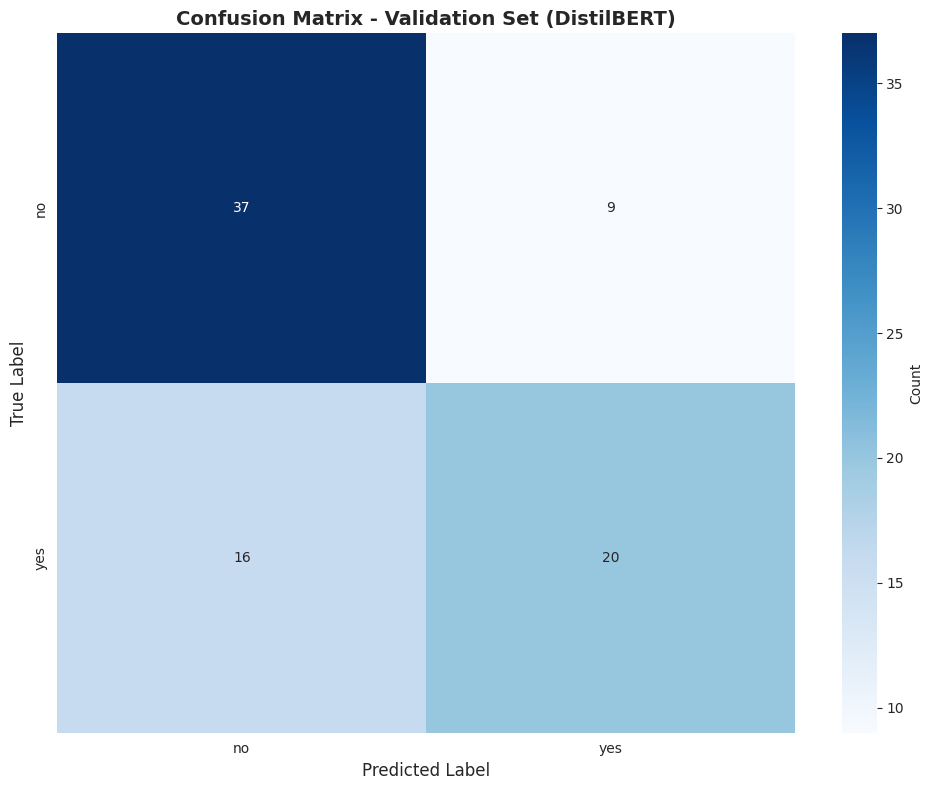


✓ Saved confusion matrix to figures/validation_confusion_matrix_deeplearning.png


In [46]:
# Confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)
print(f"\n=== Confusion Matrix ===")
print("Rows = True labels, Columns = Predicted labels")
print(f"Label order: {list(label_encoder.classes_)}")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Validation Set (DistilBERT)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()

# Save figure
figures_dir = BASE / 'figures'
figures_dir.mkdir(exist_ok=True)
plt.savefig(figures_dir / 'validation_confusion_matrix_deeplearning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved confusion matrix to figures/validation_confusion_matrix_deeplearning.png")


## Sample Predictions


In [47]:
# Compare predictions with true labels for some examples
print("\n=== Sample Predictions ===")
sample_indices = np.random.choice(len(validation_df), size=min(10, len(validation_df)), replace=False)

results_df = pd.DataFrame({
    'true_label': [y_true_labels[i] for i in sample_indices],
    'predicted_label': [y_pred_labels[i] for i in sample_indices],
    'text_preview': [validation_df.iloc[i]['text'][:100] + '...' for i in sample_indices],
    'correct': [y_true_labels[i] == y_pred_labels[i] for i in sample_indices]
})

print(results_df.to_string(index=False))

print(f"\n✓ Validation set evaluation complete!")
print(f"  Total validation samples: {len(validation_df)}")
print(f"  Accuracy: {val_accuracy:.4f}")
print(f"  Correct predictions: {(np.array(y_true_labels) == np.array(y_pred_labels)).sum()}/{len(y_true_labels)}")



=== Sample Predictions ===
true_label predicted_label                                                                                               text_preview  correct
        no              no    The rapture has been taught in Western churches beginning with John Darby's theory in the 1830s. The...     True
        no              no  yeah, this stuff is GREAT for tripping. \n I would value these songs, and would have,  years  ago. \n ...     True
       yes             yes    Jeffrey Epstein's famous little black book, full of hundreds of well-known elites, celebrities, and ...     True
        no              no    The Iraq war was a disaster. Thousands of Americans dead, the war cost TRILLIONS. But the invasion o...     True
       yes              no    Though denied by HAARP project officials, some respected researchers allege that the electromagnetic...    False
        no              no    a hospital that receives money from the state and federal governments has begun deny

## Summary

This deep learning approach:
- **Binary classification (yes/no only)**: Same setup as other ML notebooks — "cant_tell" samples are excluded
- **Uses only text and labels**: No engineered features needed - the transformer model learns representations directly from text
- **Model**: DistilBERT (lightweight BERT variant) for efficient training
- **Advantages**: 
  - Can capture complex semantic patterns in text
  - No feature engineering required
  - Transfer learning from pre-trained language model
- **Comparison with feature-based models**: Deep learning models often perform better on text classification tasks, especially when there's sufficient training data

**Note**: For production use, you might want to:
- Experiment with different transformer models (BERT, RoBERTa, etc.)
- Tune hyperparameters (learning rate, batch size, epochs)
- Use early stopping based on validation performance
- Apply class weighting if there's class imbalance
